# HPOP pipeline on SWE-rebench-openhands — the 6 stages

Primary benchmark: `nebius/SWE-rebench-openhands-trajectories`. We walk **one trajectory** end-to-end through the standard pipeline:

| # | stage | produced by | status |
|---|-------|-------------|--------|
| 1 | **raw input** | the dataset (OpenHands messages) | given |
| 2 | **events** | `ingest/swe_rebench.py` | built |
| 3 | **events → CPA** | `annotate/opencode.py` (LLM, INDUCE/APPLY) | built (needs key for real batch) |
| 4 | **CPA → skills** | HPOP | downstream — illustrated |
| 5 | **local posets** (per skill) | HPOP | downstream — illustrated |
| 6 | **global poset** (over skills) | HPOP | downstream — illustrated |

Stages 1–3 run on real data/pipeline; 4–6 show what the **downstream HPOP model** learns (illustrative until `src/hpop/inference/` is implemented).

In [1]:
%matplotlib inline
import json, os
from collections import Counter
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

ROOT = os.path.abspath('..') if os.path.basename(os.getcwd())=='notebooks' else os.getcwd()
D = os.path.join(ROOT,'data','interim','swe_rebench')
T = {json.loads(l)['trace_id']: json.loads(l) for l in open(os.path.join(D,'pilot100.jsonl'))}
TID = 'tianocore__edk2-pytool-library-372'
traj = T[TID]
print('pilot:', len(T), 'trajectories | walking:', TID, '| repo', traj['repo'], '| resolved', traj['resolved'], '|', traj['num_action_tokens'],'actions')

FAMC = {'read':'#7c9cff','execute':'#f78bb0','search':'#e3b341','edit':'#5fd0a8','test':'#d98a5f','think':'#9aa7b4','submit':'#9b8cff','install':'#56c2d6','other':'#777'}
RELC = {'DATA_FLOW':'#1f77b4','STATE_CHANGE':'#2ca02c','PRECONDITION':'#ff7f0e','VERIFY_OF':'#9467bd','REPAIR_OF':'#d62728','ELABORATES':'#8c564b','INCOMPARABLE':'#7f7f7f'}
def draw_dag(ax, pos, labels, edges, node_colors, title=''):
    for s,t,rel in edges:
        if s in pos and t in pos:
            (x1,y1),(x2,y2)=pos[s],pos[t]; dash=(0,(4,3)) if rel=='INCOMPARABLE' else 'solid'
            style='-' if rel=='INCOMPARABLE' else '-|>'
            ax.add_patch(FancyArrowPatch((x1,y1),(x2,y2),connectionstyle='arc3,rad=0.18',arrowstyle=style,mutation_scale=11,lw=1.6,color=RELC.get(rel,'#999'),linestyle=dash,zorder=1))
    for i,(x,y) in pos.items():
        ax.scatter([x],[y],s=430,color=node_colors.get(i,'#888'),edgecolors='white',zorder=2)
        ax.text(x,y,str(i),ha='center',va='center',color='white',fontsize=8,weight='bold',zorder=3)
        ax.text(x,y-0.36,labels[i],ha='center',va='top',fontsize=6.5,color='#333')
    ax.set_title(title,fontsize=10); ax.axis('off')

pilot: 100 trajectories | walking: tianocore__edk2-pytool-library-372 | repo tianocore/edk2-pytool-library | resolved True | 45 actions


## Stage 1 — Raw input (OpenHands messages)
A trajectory is a list of role-tagged messages: `assistant` turns carry **one tool call** whose `arguments` are a **JSON string** (deserialized at ingest); `tool` turns carry the **observation**.

In [2]:
raw = json.load(open(os.path.join(D,'raw_example.json')))
print('raw example:', raw['instance_id'], '| resolved', raw['resolved'], '\n')
for m in raw['messages'][:6]:
    role=m.get('role'); tc=m.get('tool_calls')
    if tc:
        fn=tc[0]['function']; print(f"[{role}] tool_call: {fn['name']}  arguments(JSON str)= {str(fn['arguments'])[:90]}")
    else:
        print(f"[{role}] {str(m.get('content'))[:90]}")

raw example: PlasmaFAIR__sdf-xarray-24 | resolved 0 

[system] You are OpenHands agent, a helpful AI assistant that can interact with a computer to solve
[user] <uploaded_files>
/workspace/PlasmaFAIR__sdf-xarray__unknown
</uploaded_files>

I've upload
[assistant] tool_call: think  arguments(JSON str)= {"thought": "Let me analyze the issue description:\n\n1. The error message indicates that 
[tool] Your thought has been logged.
[assistant] tool_call: str_replace_editor  arguments(JSON str)= {"command": "view", "path": "/workspace"}
[tool] Here's the files and directories up to 2 levels deep in /workspace, excluding hidden items


## Stage 2 — Events
`ingest/swe_rebench.py` pairs each `assistant` tool call with its following `tool` observation into one **event** `(tool, command, observation, order, after_fail)`. `after_fail` flags steps following a failure.

45 events

  e0000       think    think              think                                        -> Your thought has been logged.
  e0001       read     str_replace_editor view(/workspace)                             -> Here's the files and directori
  e0002       execute  execute_bash       cd /workspace/tianocore__edk2-pytool-library -> /workspace/tianocore__edk2-pyt
  e0003       read     str_replace_editor view(/workspace/tianocore__edk2-pytool-libra -> Here's the result of running `
  e0004       search   execute_bash       cd /workspace/tianocore__edk2-pytool-library -> ./tests.unit/test_ansi_handler
  e0005       test     execute_bash       cd /workspace/tianocore__edk2-pytool-library -> usage: __main__.py [options] [
  e0006 FAIL> test     execute_bash       cd /workspace/tianocore__edk2-pytool-library -> ============================= 
  e0007       search   execute_bash       cd /workspace/tianocore__edk2-pytool-library -> cd /workspace/tianocore__edk2-
  e0008       read    

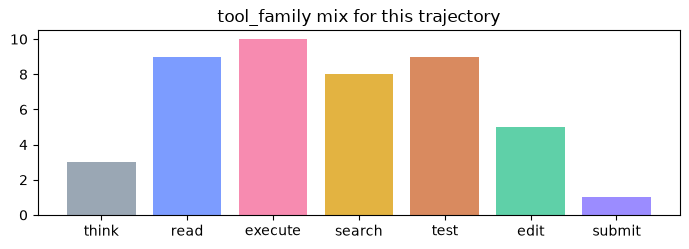

In [3]:
ev = traj['action_tokens']
print(f'{len(ev)} events\n')
for x in ev[:16]:
    fl='FAIL>' if x.get('after_fail') else '     '
    print(f"  e{x['i']:04d} {fl} {x['tool_family']:<8} {x['tool_name']:<18} {x['command'][:44]:<44} -> {(x['observation'] or '')[:30]}")
print('   ...')
fam=Counter(x['tool_family'] for x in ev)
fig,ax=plt.subplots(figsize=(7,2.6)); k=list(fam); ax.bar(k,[fam[i] for i in k],color=[FAMC.get(i,'#777') for i in k])
ax.set_title('tool_family mix for this trajectory'); plt.tight_layout(); plt.show()

## Stage 3 — Events → CPA (occurrence-level)
`annotate/opencode.py` groups events into **Canonical Procedural Action** occurrences (induced, not predefined). A tool call ≠ a CPA: `execute_bash` becomes RUN_TEST_SUITE / SEARCH_CODE_SYMBOL / RUN_REPRODUCTION depending on context. Repeats are preserved as separate occurrences.

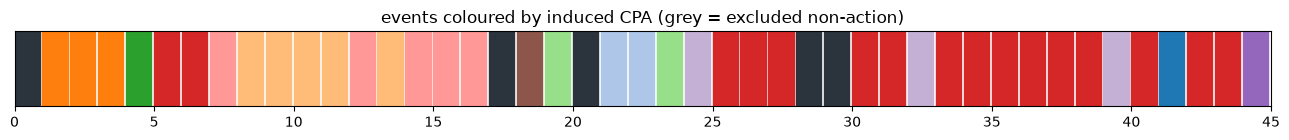

14 CPA occurrences from 45 events; 11 distinct CPAs; excluded 3 (think)

example occurrence record:
{
  "occurrence_id": "tianocore__edk2-pytool-library-372::CPA_0003",
  "source_event_ids": [
    "e0005",
    "e0006"
  ],
  "start_event_id": "e0005",
  "end_event_id": "e0006",
  "decision": "PROPOSE_NEW",
  "canonical_label": null,
  "candidate_label": "RUN_TEST_SUITE",
  "definition": "Execute the project test suite to observe pass/fail status.",
  "procedural_function": "execute the project test suite to observe pass/fail status.",
  "input_artifacts": [
    {
      "artifact": "prior state",
      "evidence_event_ids": [
        "e0005"
      ]
   


In [4]:
ann = json.loads(open(os.path.join(ROOT,'data','annotated','swe_rebench','cpa_demo.jsonl')).read().splitlines()[0])
occ = ann['cpa_instances']
eid2i = lambda e:int(str(e).lstrip('e'))
# map each event -> its CPA candidate_label
tok2lab={}
for c in occ:
    for e in c['source_event_ids']: tok2lab[eid2i(e)]=c['candidate_label']
labels=sorted({c['candidate_label'] for c in occ})
cpac=dict(zip(labels, plt.cm.tab20.colors))
fig,ax=plt.subplots(figsize=(13,1.5))
for x in ev:
    lab=tok2lab.get(x['i']); col=cpac.get(lab,'#2b333d')
    ax.add_patch(plt.Rectangle((x['i'],0),0.9,1,color=col)); 
ax.set_xlim(0,len(ev)); ax.set_ylim(0,1); ax.set_yticks([]); ax.set_title('events coloured by induced CPA (grey = excluded non-action)')
plt.tight_layout(); plt.show()
print(f'{len(occ)} CPA occurrences from {len(ev)} events; {len(set(labels))} distinct CPAs; excluded {len(ann["excluded_events"])} (think)')
print('\nexample occurrence record:'); print(json.dumps(occ[2], indent=2)[:560])

## Stage 4 — CPA → skills
The **downstream HPOP model** groups recurring CPA sub-sequences into reusable **skill instances** (a skill = a local partial order over CPAs). Shown here as an illustrative segmentation of this trajectory's CPA occurrences into three skills.

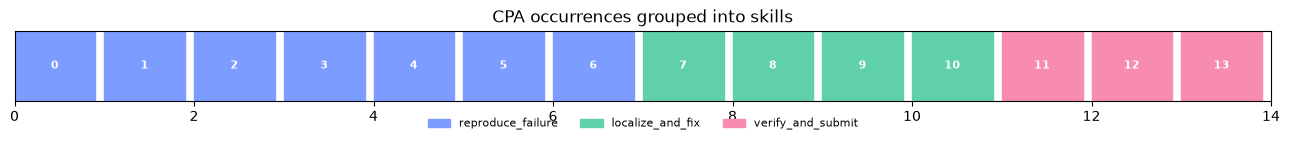

  S1 reproduce_failure   : EXPLORE_REPOSITORY -> LOCATE_TESTS -> RUN_TEST_SUITE -> SEARCH_CODE_SYMBOL -> INSPECT_SOURCE -> WRITE_REPRODUCTION_SCRIPT -> RUN_REPRODUCTION
  S2 localize_and_fix    : EDIT_SOURCE_TO_FIX -> RUN_REPRODUCTION -> WRITE_REGRESSION_TEST -> RUN_TEST_SUITE
  S3 verify_and_submit   : CLEANUP_ARTIFACTS -> RUN_TEST_SUITE -> SUBMIT_SOLUTION


In [5]:
SKILLS=[('S1','reproduce_failure','#7c9cff',[0,1,2,3,4,5,6]),
        ('S2','localize_and_fix','#5fd0a8',[7,8,9,10]),
        ('S3','verify_and_submit','#f78bb0',[11,12,13])]
lab=[c['candidate_label'] for c in occ]
occ2skill={i:s[0] for s in SKILLS for i in s[3]}
skcol={s[0]:s[2] for s in SKILLS}
fig,ax=plt.subplots(figsize=(13,1.6))
for i,c in enumerate(occ):
    ax.add_patch(plt.Rectangle((i,0),0.9,1,color=skcol[occ2skill[i]]))
    ax.text(i+0.45,0.5,str(i),ha='center',va='center',color='white',fontsize=8,weight='bold')
ax.set_xlim(0,len(occ)); ax.set_ylim(0,1); ax.set_yticks([]); ax.set_title('CPA occurrences grouped into skills')
ax.legend(handles=[plt.Rectangle((0,0),1,1,color=s[2],label=s[1]) for s in SKILLS], ncol=3, loc='upper center', bbox_to_anchor=(0.5,-0.1), fontsize=8, frameon=False)
plt.tight_layout(); plt.show()
for s in SKILLS: print(f"  {s[0]} {s[1]:<20}: "+' -> '.join(lab[i] for i in s[3]))

## Stage 5 — Local posets (per skill)
Within each skill, HPOP recovers a **local partial order** over its CPA occurrences. Edge colour = dependency relation; **INCOMPARABLE** (dashed) = order-free → runs in parallel.

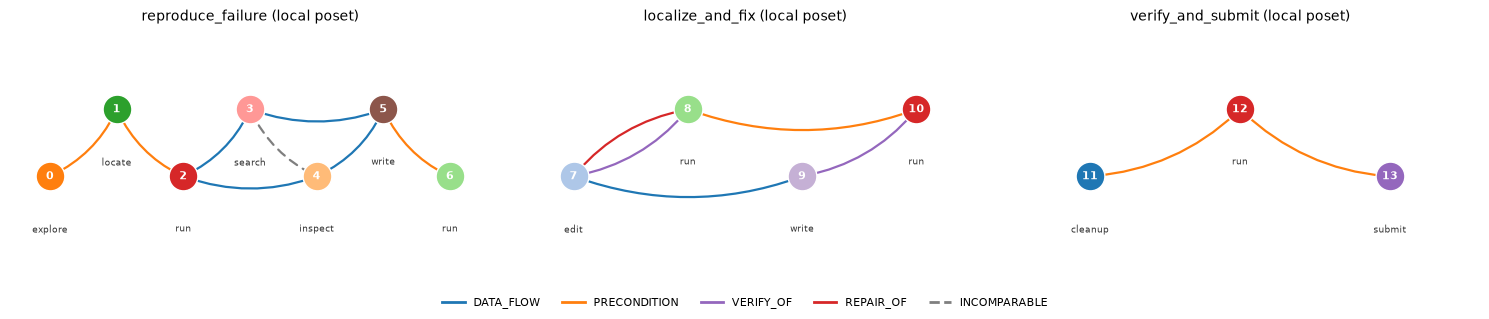

In [6]:
LOCAL=[(0,1,'PRECONDITION'),(1,2,'PRECONDITION'),(2,3,'DATA_FLOW'),(2,4,'DATA_FLOW'),(3,4,'INCOMPARABLE'),
       (3,5,'DATA_FLOW'),(4,5,'DATA_FLOW'),(5,6,'PRECONDITION'),
       (7,8,'VERIFY_OF'),(8,7,'REPAIR_OF'),(7,9,'DATA_FLOW'),(9,10,'VERIFY_OF'),(8,10,'PRECONDITION'),
       (11,12,'PRECONDITION'),(12,13,'PRECONDITION')]
ncol={i:cpac.get(lab[i],'#888') for i in range(len(occ))}
fig,axs=plt.subplots(1,3,figsize=(15,3.2))
for ax,s in zip(axs,SKILLS):
    idxs=s[3]; pos={i:(j,(0.5 if j%2 else 0)) for j,i in enumerate(idxs)}
    eds=[(a,b,r) for (a,b,r) in LOCAL if a in idxs and b in idxs]
    draw_dag(ax,pos,{i:lab[i].split('_')[0].lower() for i in idxs},eds,ncol,title=f'{s[1]} (local poset)')
    ax.set_xlim(-0.6,len(idxs)-0.4); ax.set_ylim(-0.8,1.1)
hs=[plt.Line2D([0],[0],color=RELC[r],lw=2,ls='--' if r=='INCOMPARABLE' else '-',label=r) for r in ['DATA_FLOW','PRECONDITION','VERIFY_OF','REPAIR_OF','INCOMPARABLE']]
fig.legend(handles=hs,ncol=5,loc='lower center',fontsize=8,frameon=False); plt.tight_layout(rect=[0,0.05,1,1]); plt.show()

## Stage 6 — Global poset (over skills)
Finally HPOP recovers the **global partial order over skill instances** — the workflow grammar. Skill types are the reusable library `R`; a new skill is penalized (see `docs/MODEL.md`).

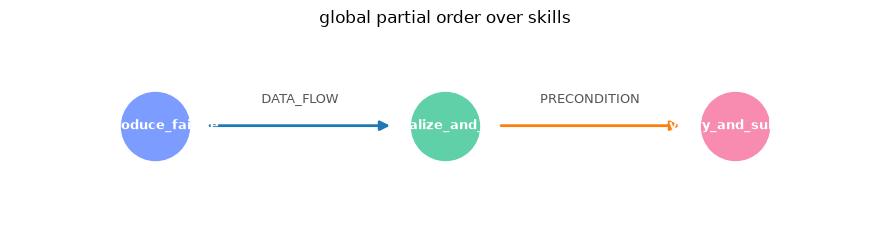

workflow grammar: reproduce_failure -> localize_and_fix -> verify_and_submit


In [7]:
GLOBAL=[('S1','S2','DATA_FLOW'),('S2','S3','PRECONDITION')]
pos={'S1':(0,0),'S2':(1,0),'S3':(2,0)}
fig,ax=plt.subplots(figsize=(9,2.4))
for s,t,rel in GLOBAL:
    (x1,y1),(x2,y2)=pos[s],pos[t]; ax.add_patch(FancyArrowPatch((x1+0.18,y1),(x2-0.18,y2),arrowstyle='-|>',mutation_scale=14,lw=2,color=RELC[rel]))
    ax.text((x1+x2)/2,0.12,rel,ha='center',fontsize=9,color='#555')
for sid,name,col,_ in SKILLS:
    x,y=pos[sid]; ax.scatter([x],[y],s=2600,color=col,edgecolors='white'); ax.text(x,y,name,ha='center',va='center',color='white',fontsize=9,weight='bold')
ax.set_xlim(-0.5,2.5); ax.set_ylim(-0.5,0.5); ax.axis('off'); ax.set_title('global partial order over skills')
plt.tight_layout(); plt.show()
print('workflow grammar:', ' -> '.join(s[1] for s in SKILLS))

## Recap
**raw messages → events → CPA occurrences → skills → local posets → global poset.** Stages 1–3 are the built data-prep pipeline (CPAs *induced*, data-prep only); stages 4–6 are what the HPOP model learns (BPOP frontier-softmax + DP skill library with a new-skill penalty). Run the real CPA batch with a key, then `scripts/render_from_opencode.py` re-renders stages 2–3 from actual output.